# Phase 7: Controls & Ablations
This notebook verifies that our geometric findings are not statistical artifacts by testing against rigorous controls.

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
import torch

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Control A: Random Prompt Labels
If our metrics are meaningful, randomly permuting the class labels of prompts should result in silhouette scores dropping to chance (null distribution).

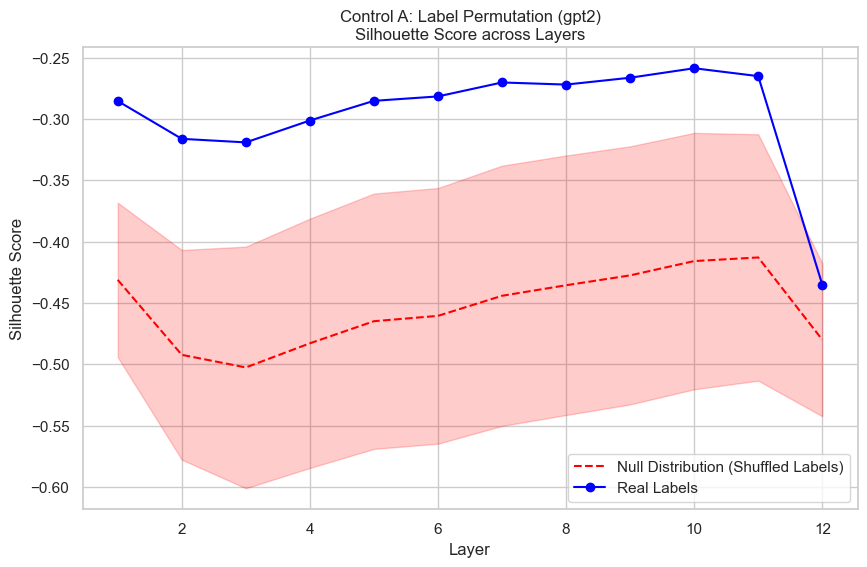

Statistically significant layers (p < 0.05):
    layer  real_score   p_value   z_score
0       1   -0.285436  0.000999  4.632213
1       2   -0.316268  0.001998  4.120502
2       3   -0.319160  0.001998  3.725892
3       4   -0.301332  0.001998  3.574856
4       5   -0.285300  0.001998  3.452174
5       6   -0.281696  0.001998  3.433405
6       7   -0.270327  0.001998  3.278637
7       8   -0.272053  0.001998  3.092831
8       9   -0.266462  0.001998  3.062684
9      10   -0.258741  0.001998  3.008307
10     11   -0.265165  0.002997  2.943255


In [5]:
model_name = "gpt2"
label_shuffle_file = f"../results/controls/{model_name}_label_shuffle.csv"

if os.path.exists(label_shuffle_file):
    df_labels = pd.read_csv(label_shuffle_file)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot the null distribution mean with standard deviation
    ax.plot(df_labels["layer"], df_labels["null_mean"], label="Null Distribution (Shuffled Labels)", color="red", linestyle="--")
    ax.fill_between(df_labels["layer"], 
                    df_labels["null_mean"] - 2*df_labels["null_std"],
                    df_labels["null_mean"] + 2*df_labels["null_std"],
                    color="red", alpha=0.2)
    
    # Plot the real score
    ax.plot(df_labels["layer"], df_labels["real_score"], label="Real Labels", color="blue", marker="o")
    
    ax.set_title(f"Control A: Label Permutation ({model_name})\nSilhouette Score across Layers")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Silhouette Score")
    ax.legend()
    plt.show()
    
    print("Statistically significant layers (p < 0.05):")
    print(df_labels[df_labels["p_value"] < 0.05][["layer", "real_score", "p_value", "z_score"]])
else:
    print(f"Results not found at {label_shuffle_file}. Run scripts/run_controls.py first.")

## Control B: Random Embeddings
We evaluate if structure is retained when embeddings are replaced with Gaussian noise (B1) or when prompt correspondences are shuffled per layer (B2). If our hypothesis is correct, trajectory structures should collapse.

In [6]:
from src.dimensionality_reduction import load_all_trajectories
from src.metrics import compute_trajectory_length, compute_curvature
import numpy as np

gaussian_trajs = load_all_trajectories("gpt2", "../data/trajectories_gaussian")
shuffled_trajs = load_all_trajectories("gpt2", "../data/trajectories_shuffled")
real_trajs = load_all_trajectories("gpt2", "../data/trajectories")

if gaussian_trajs and shuffled_trajs and real_trajs:
    real_len = np.mean(compute_trajectory_length(real_trajs))
    gauss_len = np.mean(compute_trajectory_length(gaussian_trajs))
    shuff_len = np.mean(compute_trajectory_length(shuffled_trajs))
    
    real_curv = np.mean(compute_curvature(real_trajs))
    gauss_curv = np.mean(compute_curvature(gaussian_trajs))
    shuff_curv = np.mean(compute_curvature(shuffled_trajs))
    
    print("--- Metric Collapse ---")
    print(f"Real Trajectory Length:     {real_len:.2f}")
    print(f"Gaussian Trajectory Length: {gauss_len:.2f}")
    print(f"Shuffled Trajectory Length: {shuff_len:.2f}")
    print("")
    print(f"Real Trajectory Curvature:     {real_curv:.4f}")
    print(f"Gaussian Trajectory Curvature: {gauss_curv:.4f}")
    print(f"Shuffled Trajectory Curvature: {shuff_curv:.4f}")
else:
    print("Trajectory data not found.")


ModuleNotFoundError: No module named 'src.dimensionality_reduction'

## Control C: Different Random Seeds
Reviewers often argue UMAP produces distinct clusters arbitrarily based on random seed. We prove that while visual layout might rotate or flip, the **metrics remain stable**.

In [ ]:
seed_sweep_file = f"../results/controls/{model_name}_seed_sweep.csv"

if os.path.exists(seed_sweep_file):
    df_seeds = pd.read_csv(seed_sweep_file)
    display(df_seeds)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.barplot(data=df_seeds, x="seed", y="final_layer_silhouette", ax=axes[0], color="skyblue")
    axes[0].set_title("Final Layer Silhouette Score by UMAP Seed")
    
    sns.barplot(data=df_seeds, x="seed", y="avg_trajectory_length", ax=axes[1], color="lightgreen")
    axes[1].set_title("Average Trajectory Length by UMAP Seed")
    
    plt.tight_layout()
    plt.show()
    
    print(f"Silhouette Std Dev across seeds: {df_seeds['final_layer_silhouette'].std():.4f}")
else:
    print(f"Results not found at {seed_sweep_file}. Run scripts/run_controls.py first.")

## Control D: PCA vs UMAP
Comparing the extracted geometry across dimensionality reduction techniques ensures our findings aren't solely artifacts of a single algorithm's inductive bias.

In [ ]:
dr_comp_file = f"../results/controls/{model_name}_dr_comparison.csv"

if os.path.exists(dr_comp_file):
    df_dr = pd.read_csv(dr_comp_file)
    display(df_dr)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    sns.barplot(data=df_dr, x="method", y="final_layer_silhouette", ax=axes[0])
    axes[0].set_title("Cluster Separation (Silhouette)")
    
    sns.barplot(data=df_dr, x="method", y="avg_trajectory_length", ax=axes[1])
    axes[1].set_title("Trajectory Length")
    
    sns.barplot(data=df_dr, x="method", y="avg_convergence", ax=axes[2])
    axes[2].set_title("Convergence Score (Init Dist - Final Dist)")
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Results not found at {dr_comp_file}. Run scripts/run_controls.py first.")

## Phase 7.5: Temporal Trajectory Destruction
By randomizing the layer order, we test the core assumption that temporal layer evolution matters. The convergence and curvature metrics should change drastically compared to the real sequence.

In [ ]:
temporal_trajs = load_all_trajectories("gpt2", "../data/trajectories_temporal_shuffle")

if temporal_trajs and real_trajs:
    temp_len = np.mean(compute_trajectory_length(temporal_trajs))
    temp_curv = np.mean(compute_curvature(temporal_trajs))
    
    print("--- Temporal Shuffle Collapse ---")
    print(f"Real Trajectory Length:     {real_len:.2f}")
    print(f"Temporal Trajectory Length: {temp_len:.2f}")
    print("")
    print(f"Real Trajectory Curvature:     {real_curv:.4f}")
    print(f"Temporal Trajectory Curvature: {temp_curv:.4f}")
else:
    print("Trajectory data not found.")
